# SWaT — Secure Water Treatment: dataset analysis

## What the dataset contains

SWaT is the **Secure Water Treatment** testbed at iTrust, Singapore University of
Technology and Design: a water purification plant in miniature but genuinely
operational, built as a test bench for industrial control system security. It
produces 5 gallons per minute of treated water through **six process stages** in
sequence:

| stage | function |
|---|---|
| P1 | raw water intake and storage |
| P2 | chemical dosing (NaOCl, HCl) with pH and conductivity measurement |
| P3 | ultrafiltration (UF) |
| P4 | dechlorination by UV lamps |
| P5 | reverse osmosis (RO) |
| P6 | recirculation and backwash cleaning |

The instrumentation is of two different natures, and the distinction matters for
any analysis: **sensors** measuring a numeric quantity (flow, level, pressure,
pH) and **actuators** holding a discrete state (pumps on/off, valves
open/closed). Everything is sampled at **1 Hz**.

The recording spans 12 calendar dates: the first 7 under normal operation, the remaining 6 — overlapping the seventh — containing the attacks. There are **41 attacks executed physically on the PLCs** — manipulating the values sent to
actuators and the values read from sensors — with every instant labelled `Normal`
or `Attack`.

## Where to download it

> **Kaggle:** <https://www.kaggle.com/datasets/vishala28/swat-dataset-secure-water-treatment-system>

This redistribution ships **three CSV files**:

| file | what it holds |
|---|---|
| `normal.csv` | only the rows labelled `Normal` |
| `attack.csv` | only the rows labelled `Attack` |
| `merged.csv` | every row, normal and attack together |

For this project, we consider only the merged version.


In [17]:
from pathlib import Path
import re

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

DATA = Path("../data/raw/swat/swat.csv")
DECLARED = Path("../data/raw/categorical_columns.yaml")
CATEGORICAL = yaml.safe_load(DECLARED.read_text(encoding="utf-8"))["swat"]

SURFACE, INK, INK2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
GRID, AXIS = "#e1e0d9", "#c3c2b7"
C = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
NORMAL, ATTACK = C[0], "#d03b3b"   # attack uses the critical status step: it means "bad"
SEQ = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
       "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "grid.linestyle": "-", "axes.axisbelow": True,
    "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "axes.titlesize": 11, "axes.labelsize": 9.5,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "figure.dpi": 110,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
})
print("pandas", pd.__version__, "| matplotlib", mpl.__version__)

pandas 3.0.6 | matplotlib 3.11.2


---
## 1. Loading and shape

The column names in the original file carry leading or trailing spaces
(` Timestamp`, ` MV101`, ` AIT201`…), **the same spaces are in the timestamp
values** (`" 28/12/2015 10:00:00 AM"`), and in this redistribution some labels
appear as `A ttack`. All of it has to be normalised **before** any comparison: a
label that fails to match would be read as normal, and the dataset would come out
with no positives.

In [18]:
df = pd.read_csv(DATA, low_memory=False)
df.columns = [str(c).strip() for c in df.columns]
df["Normal/Attack"] = df["Normal/Attack"].astype(str).str.strip().str.replace(" ", "", regex=False)
df["Timestamp"] = df["Timestamp"].astype(str).str.strip()

LABEL, TIME = "Normal/Attack", "Timestamp"
instruments = [c for c in df.columns if c not in (LABEL, TIME)]

print(f"rows        : {len(df):,}")
print(f"columns     : {df.shape[1]}  =  1 timestamp + {len(instruments)} instruments + 1 label")
print(f"labels      : {df[LABEL].value_counts().to_dict()}")
print(f"memory      : {df.memory_usage(deep=True).sum() / 1e6:,.0f} MB")
df.head(3)

rows        : 1,441,719
columns     : 53  =  1 timestamp + 51 instruments + 1 label
labels      : {'Normal': 1387098, 'Attack': 54621}
memory      : 651 MB


,Timestamp,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,...,P501,P502,PIT501,PIT502,PIT503,FIT601,P601,P602,P603,Normal/Attack
0,28/12/2015 10:00:00 AM,2.427057,522.8467,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.5988,0.000128,1,1,1,Normal
1,28/12/2015 10:00:01 AM,2.446274,522.8860,2.0,2,1,262.0161,8.396437,328.6337,2.445391,...,2,1,250.8652,1.649953,189.6789,0.000128,1,1,1,Normal
2,28/12/2015 10:00:02 AM,2.489191,522.8467,2.0,2,1,262.0161,8.394514,328.6337,2.442316,...,2,1,250.8812,1.649953,189.6789,0.000128,1,1,1,Normal


---
## 2. Which variables are present

The 51 instruments follow a strict naming convention that encodes everything:

```
            P  101
            │   │└─ sequence number within the stage
            │   └── process stage (1-6)
            └────── instrument type
```

| code | instrument | nature |
|---|---|---|
| `FIT` | Flow Indicator Transmitter — flow rate | numeric |
| `LIT` | Level Indicator Transmitter — tank level | numeric |
| `PIT` | Pressure Indicator Transmitter — pressure | numeric |
| `DPIT` | Differential Pressure Indicator Transmitter | numeric |
| `AIT` | Analyser Indicator Transmitter — pH, conductivity, ORP | numeric |
| `MV` | Motorized Valve | categorical |
| `P` | Pump | categorical |
| `UV` | UV dechlorinator lamp | categorical |

In [19]:
def decode(name: str):
    # Split an instrument name into (type, stage) using the SWaT convention.
    m = re.match(r"^([A-Z]+)(\d)(\d+)$", name)
    return (m.group(1), int(m.group(2))) if m else ("?", 0)

meta = pd.DataFrame(
    [(c, *decode(c)) for c in instruments], columns=["instrument", "type", "stage"]
)
meta["nature"] = np.where(meta["instrument"].isin(CATEGORICAL),
                          "categorical", "numeric")

values = df[instruments].apply(pd.to_numeric, errors="coerce")
meta["levels"] = [int(values[c].nunique()) for c in instruments]
meta["missing"] = [int(values[c].isna().sum()) for c in instruments]

print(meta.groupby(["nature", "type"]).agg(n=("instrument", "size")).to_string())
print()
print("instruments per stage (stage: #instruments):", meta.groupby("stage").size().to_dict())
print()

                   n
nature      type    
categorical MV     6
            P     19
            UV     1
numeric     AIT    9
            DPIT   1
            FIT    9
            LIT    3
            PIT    3

instruments per stage (stage: #instruments): {1: 5, 2: 11, 3: 9, 4: 9, 5: 13, 6: 4}



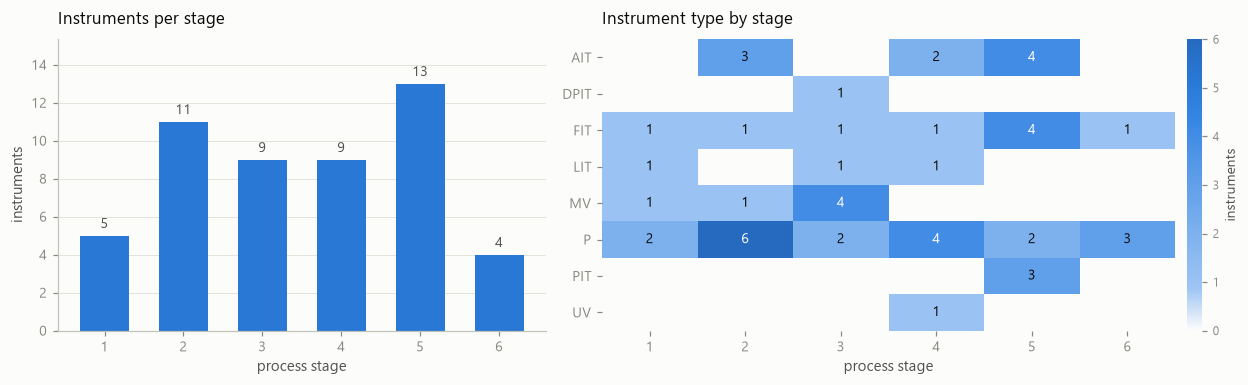

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.6), gridspec_kw={"width_ratios": [1, 1.25]})

per_stage = meta.groupby("stage").size()
ax1.bar(per_stage.index, per_stage.values, color=C[0], width=0.62)
for x, v in zip(per_stage.index, per_stage.values):
    ax1.text(x, v + 0.25, str(v), ha="center", va="bottom", color=INK2, fontsize=9)
ax1.set(xlabel="process stage", ylabel="instruments",
        title="Instruments per stage", ylim=(0, per_stage.max() * 1.18))
ax1.set_xticks(per_stage.index)
ax1.grid(axis="x", visible=False)

cross = pd.crosstab(meta["type"], meta["stage"])
cmap = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#fcfcfb"] + SEQ[2:9])
im = ax2.imshow(cross.values, cmap=cmap, aspect="auto", vmin=0, vmax=cross.values.max())
ax2.set_xticks(range(cross.shape[1]), cross.columns)
ax2.set_yticks(range(cross.shape[0]), cross.index)
for i in range(cross.shape[0]):
    for j in range(cross.shape[1]):
        v = cross.values[i, j]
        if v:
            ax2.text(j, i, str(v), ha="center", va="center", fontsize=9,
                     color="#ffffff" if v > cross.values.max() * 0.6 else INK)
ax2.set(xlabel="process stage", title="Instrument type by stage")
ax2.grid(visible=False)
for s in ax2.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax2, fraction=0.04, pad=0.02)
cb.set_label("instruments", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

**Stage 5 is the most instrumented** (13 instruments): it is reverse osmosis,
where four flow measurements and three pressure measurements are needed.
Stage 2 follows with 11 — chemical dosing, with six dosing pumps
and three analysers. Stage 6 has only 4: recirculation is the simplest subsystem.

**Pumps (`P`) are 19 of 51**, more than a third of the instrumentation, and they
are all categorical variables with two or three levels.

---
## 3. Data quality

In [21]:
dup = df.duplicated(keep="first")
print(f"duplicate rows (identical across all 53 columns) : {dup.sum():,}  "
      f"({dup.mean():.1%} of the file)")
print(f"duplicate timestamps                            : {df[TIME].duplicated().sum():,}")
print(f"unique rows                                     : {(~dup).sum():,}")
print()
print("A third of the file is an exact copy of itself, timestamps included.")

duplicate rows (identical across all 53 columns) : 495,000  (34.3% of the file)
duplicate timestamps                            : 495,000
unique rows                                     : 946,719

A third of the file is an exact copy of itself, timestamps included.


In [22]:
ts = pd.to_datetime(df[TIME], format="%d/%m/%Y %I:%M:%S %p")
gaps = ts.diff().dt.total_seconds()
back = np.flatnonzero((gaps < 0).to_numpy())
print(f"sampling: {(gaps == 1.0).sum():,} one-second intervals out of {len(gaps) - 1:,}  -> 1 Hz")
print(f"backward time jumps: {len(back)}  at rows {back.tolist()}")
print(f"interval covered: {ts.min()}  ->  {ts.max()}")
print()
cuts = [0, *back.tolist(), len(df)]
is_attack = (df[LABEL] == "Attack").to_numpy()
for i in range(len(cuts) - 1):
    a, b = cuts[i], cuts[i + 1]
    print(f"block {i + 1}: rows {a:>9,}-{b - 1:<9,} ({b - a:>7,})  "
          f"{ts.iloc[a]} -> {ts.iloc[b - 1]}  "
          f"attacks {is_attack[a:b].sum():>6,} ({is_attack[a:b].mean():6.2%})  "
          f"duplicates {dup.to_numpy()[a:b].sum():>7,}")

sampling: 1,441,645 one-second intervals out of 1,441,718  -> 1 Hz
backward time jumps: 2  at rows [395298, 892098]
interval covered: 2015-12-22 16:00:00  ->  2016-01-02 14:59:59

block 1: rows         0-395,297   (395,298)  2015-12-28 10:00:00 -> 2016-01-02 14:59:59  attacks      0 ( 0.00%)  duplicates       0
block 2: rows   395,298-892,097   (496,800)  2015-12-22 16:00:00 -> 2015-12-28 09:59:59  attacks      0 ( 0.00%)  duplicates       0
block 3: rows   892,098-1,441,718 (549,621)  2015-12-22 16:30:00 -> 2016-01-02 13:41:11  attacks 54,621 ( 9.94%)  duplicates 495,000


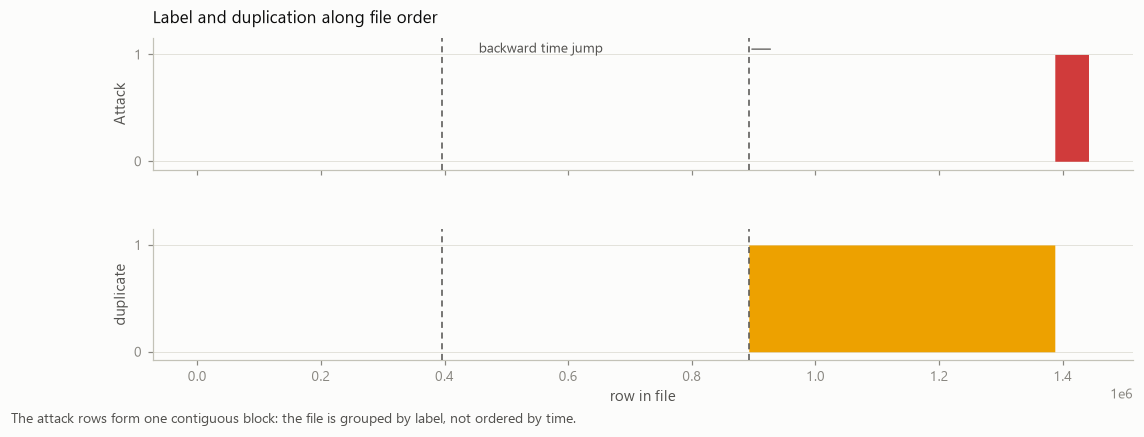

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(11.5, 3.8), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1], "hspace": 0.45})

idx = np.arange(len(df))
stride = 200  
axes[0].fill_between(idx[::stride], 0, is_attack[::stride].astype(int),
                     step="mid", color=ATTACK, linewidth=0)
axes[0].set(ylabel="Attack", yticks=[0, 1], ylim=(-0.08, 1.15),
            title="Label and duplication along file order")
axes[1].fill_between(idx[::stride], 0, dup.to_numpy()[::stride].astype(int),
                     step="mid", color=C[3], linewidth=0)
axes[1].set(ylabel="duplicate", yticks=[0, 1], ylim=(-0.08, 1.15), xlabel="row in file")

for ax in axes:
    ax.grid(axis="x", visible=False)
    for b in back:
        ax.axvline(b, color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)

axes[0].annotate("backward time jump", xy=(back[0], 1.05),
                 xytext=(back[0] + 60000, 1.05), color=INK2, fontsize=9, va="center")
axes[0].annotate("", xy=(back[1], 1.05), xytext=(back[1] + 40000, 1.05),
                 arrowprops=dict(arrowstyle="-", color=INK2, lw=0.8))
fig.text(0.013, -0.04, "The attack rows form one contiguous block: the file is grouped "
         "by label, not ordered by time.", color=INK2, fontsize=9)
plt.show()

The chart shows three defects together, and they are visible only in row
order — any aggregate hides them:

1. **The file is three concatenated blocks**, separated by two backward time
   jumps. Block 1 covers 28/12→02/01, block 2 goes back to 22/12, block 3 starts
   from 22/12 again. A temporal split taken on file order would read interleaved
   periods.
2. **A third of the file is duplicated**, and the duplicates are all in block 3.
3. **The attacks are grouped into one contiguous block** at the end.

In [24]:
missing = meta[meta["missing"] > 0].sort_values("instrument")
print(f"{len(missing)} instruments with missing values, all with the same count:")
print(missing[["instrument", "type", "stage", "missing"]].to_string(index=False))
print()
present = len(df) - int(missing["missing"].iloc[0])
print(f"present in only {present:,} rows out of {len(df):,}")
print(f"= exactly the rows of the attack period ({present:,})")
print()
BOUNDARY = pd.Timestamp("2015-12-28 10:00:00")
before = (ts < BOUNDARY).to_numpy()
blank = values[missing["instrument"].tolist()].isna().all(axis=1).to_numpy()
for name, sel in (("normal period (before the boundary)", before),
                 ("labelled Normal, inside the attack period", ~before & ~is_attack),
                 ("labelled Attack", ~before & is_attack)):
    print(f"  {name:<44} {sel.sum():>9,} rows, empty {blank[sel].mean():>7.2%}")
print()
print(f"last empty row : {ts[blank].max()}")
print(f"first full row : {ts[~blank].min()}")
print(f"exceptions to the rule: {int((blank & ~before).sum() + (~blank & before).sum())}")

7 instruments with missing values, all with the same count:
instrument type  stage  missing
    AIT201  AIT      2   991800
     MV101   MV      1   991800
     MV201   MV      2   991800
     MV303   MV      3   991800
      P201    P      2   991800
      P202    P      2   991800
      P204    P      2   991800

present in only 449,919 rows out of 1,441,719
= exactly the rows of the attack period (449,919)

  normal period (before the boundary)            991,800 rows, empty 100.00%
  labelled Normal, inside the attack period      395,298 rows, empty   0.00%
  labelled Attack                                 54,621 rows, empty   0.00%

last empty row : 2015-12-28 09:59:59
first full row : 2015-12-28 10:00:00
exceptions to the rule: 0


**Seven instruments carry no values before 28/12 10:00:00**: `MV101` (stage 1),
`AIT201`, `MV201`, `P201`, `P202`, `P204` (stage 2) and `MV303` (stage 3) — one
analyser, three dosing pumps and three valves.

---
## 4. The corrected view: de-duplicated and time-ordered

Everything that follows uses the de-duplicated, timestamp-ordered file, which is
the reconstruction of the original series. The arithmetic closes **exactly** on
the published figures — but only because the timestamp values were normalised
before de-duplicating: 9 rows differ from another row by nothing but that leading
space, and without the strip they survive as near-duplicates and the count does
not close.

In [25]:
clean = df.loc[~dup].copy()
clean["ts"] = ts.loc[~dup]
clean = clean.sort_values("ts").reset_index(drop=True)
y = (clean[LABEL] == "Attack").to_numpy()

print(f"unique rows      : {len(clean):,}")
print(f"attacks          : {y.sum():,}  ({y.mean():.2%})")
print(f"interval         : {clean['ts'].min()}  ->  {clean['ts'].max()}")
print()
SPLIT = pd.Timestamp("2015-12-28 10:00:00")
n_train = int((clean["ts"] < SPLIT).sum())
n_test = len(clean) - n_train
print(f"normal period  (< {SPLIT:%d/%m %H:%M}) : {n_train:,} rows, "
      f"{y[:n_train].sum():,} attacks")
print(f"attack period  (>= {SPLIT:%d/%m %H:%M}): {n_test:,} rows, "
      f"{y[n_train:].sum():,} attacks ({y[n_train:].mean():.2%})")
print()
residual = len(clean) - (496800 + 449919)
print(f"check: 496,800 + 449,919 = {496800 + 449919:,} against {len(clean):,} measured "
      f"-> residual of {residual} rows")
print("It closes exactly because the timestamps were normalised before")
print("de-duplicating: 9 rows differ from another only by the leading space,")
print("and without that normalisation they survive and the count misses by 9.")

unique rows      : 946,719
attacks          : 54,621  (5.77%)
interval         : 2015-12-22 16:00:00  ->  2016-01-02 14:59:59

normal period  (< 28/12 10:00) : 496,800 rows, 0 attacks
attack period  (>= 28/12 10:00): 449,919 rows, 54,621 attacks (12.14%)

check: 496,800 + 449,919 = 946,719 against 946,719 measured -> residual of 0 rows
It closes exactly because the timestamps were normalised before
de-duplicating: 9 rows differ from another only by the leading space,
and without that normalisation they survive and the count misses by 9.


In [26]:
ch = np.diff(np.r_[0, y.astype(int), 0])
starts, ends = np.flatnonzero(ch == 1), np.flatnonzero(ch == -1)
dur = ends - starts
print(f"attack segments: {len(dur)}")
print(f"duration (s): min {dur.min()} "
      f"median {np.median(dur):.0f} max {dur.max():,}")
print(f"total attack instants: {dur.sum():,}")
print()
print(f"the longest segment ({dur.max():,} s = {dur.max() / 3600:.1f} h) alone covers "
      f"{dur.max() / dur.sum():.1%} of all attack instants")

attack segments: 35
duration (s): min 101 median 444 max 35,900
total attack instants: 54,621

the longest segment (35,900 s = 10.0 h) alone covers 65.7% of all attack instants


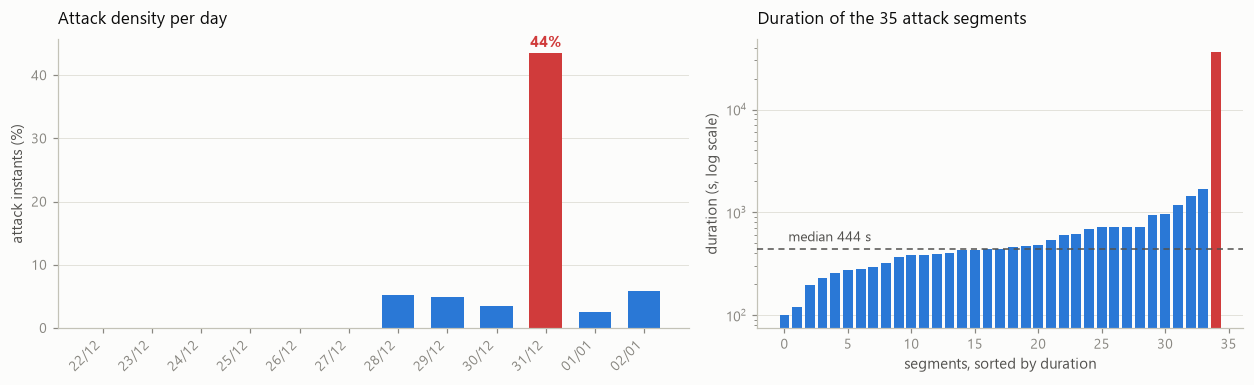

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 3.6), gridspec_kw={"width_ratios": [1.3, 1]})

per_day = pd.DataFrame({"d": clean["ts"].dt.date, "a": y}).groupby("d")["a"].agg(["size", "sum"])
per_day["rate"] = per_day["sum"] / per_day["size"]
peak = per_day["rate"].idxmax()
colors = [ATTACK if d == peak else C[0] for d in per_day.index]
ax1.bar(range(len(per_day)), per_day["rate"].values * 100, color=colors, width=0.66)
ax1.set_xticks(range(len(per_day)),
               [f"{d:%d/%m}" for d in per_day.index], rotation=45, ha="right")
ax1.set(ylabel="attack instants (%)", title="Attack density per day")
ax1.grid(axis="x", visible=False)
ax1.annotate(f"{per_day.loc[peak, 'rate']:.0%}",
             xy=(list(per_day.index).index(peak), per_day["rate"].max() * 100),
             xytext=(0, 4), textcoords="offset points", ha="center",
             color=ATTACK, fontsize=9.5, fontweight="bold")

order = np.sort(dur)
ax2.bar(range(len(order)), order, color=C[0], width=0.78)
ax2.bar([len(order) - 1], [order[-1]], color=ATTACK, width=0.78)
ax2.set_yscale("log")
ax2.axhline(np.median(dur), color=INK2, linewidth=1.0, linestyle=(0, (4, 3)), zorder=3)
ax2.text(0.3, np.median(dur) * 1.18, f"median {np.median(dur):.0f} s",
         color=INK2, fontsize=9)
ax2.set(xlabel="segments, sorted by duration", ylabel="duration (s, log scale)",
        title=f"Duration of the {len(dur)} attack segments")
ax2.grid(axis="x", visible=False)
fig.tight_layout()
plt.show()


**The attacks are not spread over time.** Six of the twelve days contain none at
all, and **31/12 alone has a density of 43.5%** against 2.5-5.8% on the other
attack days.

**The durations are heavily skewed.** Median 444 seconds, but the longest segment
runs 35,900 seconds — nearly ten hours — and alone covers 66% of all attack
instants.

---
## 5. Descriptive statistics

In [28]:
clean_vals = clean[instruments].apply(pd.to_numeric, errors="coerce")
normal_mask = (clean["ts"] < SPLIT).to_numpy()
cont = meta.loc[meta["nature"] == "numeric", "instrument"].tolist()
disc = meta.loc[meta["nature"] == "categorical", "instrument"].tolist()

desc = clean_vals.loc[normal_mask, cont].describe().T
desc[["count", "mean", "std", "min", "50%", "max"]].round(3)

,count,mean,std,min,50%,max
FIT101,496800.0,1.845,1.135,0.000,2.491,2.745
LIT101,496800.0,586.099,123.891,120.624,525.516,1000.000
AIT201,0.0,NaN,NaN,NaN,NaN,NaN
AIT202,496800.0,8.388,0.090,8.190,8.367,8.988
AIT203,496800.0,348.231,49.422,300.846,330.941,567.470
FIT201,496800.0,1.829,1.062,0.000,2.443,2.488
DPIT301,496800.0,16.561,6.765,0.000,19.832,21.099
FIT301,496800.0,1.832,0.826,0.000,2.214,2.359
LIT301,496800.0,897.535,101.992,132.818,918.595,1014.724
AIT401,496800.0,124.265,55.220,0.000,148.803,148.856


In [29]:
rows = []
for c in disc:
    s = clean_vals.loc[normal_mask, c].dropna()
    if s.empty:
        rows.append({"instrument": c, "levels": 0, "dominant state": None,
                     "dominant share": np.nan, "transitions": 0})
        continue
    vc = s.value_counts(normalize=True)
    rows.append({
        "instrument": c, "levels": int(s.nunique()),
        "dominant state": vc.index[0], "dominant share": round(float(vc.iloc[0]), 4),
        "transitions": int((s.diff() != 0).sum() - 1),
    })
actuators = pd.DataFrame(rows).sort_values("dominant share", ascending=False)
print(actuators.to_string(index=False))
print()
frozen = actuators[actuators["transitions"] <= 0]["instrument"].tolist()
print(f"actuators that never change state in the normal period ({len(frozen)}):")
print("  " + ", ".join(frozen))

instrument  levels  dominant state  dominant share  transitions
      P102       1             1.0          1.0000            0
      P404       1             1.0          1.0000            0
      P401       1             1.0          1.0000            0
      P206       1             1.0          1.0000            0
      P502       1             1.0          1.0000            0
      P601       1             1.0          1.0000            0
      P403       1             1.0          1.0000            0
      P603       1             1.0          1.0000            0
      P301       2             1.0          0.9960            9
      P402       2             2.0          0.9936            3
     UV401       2             2.0          0.9936            3
      P501       2             2.0          0.9933            1
      P602       2             1.0          0.9921          256
     MV301       3             1.0          0.9877          512
     MV304       3             1.0      

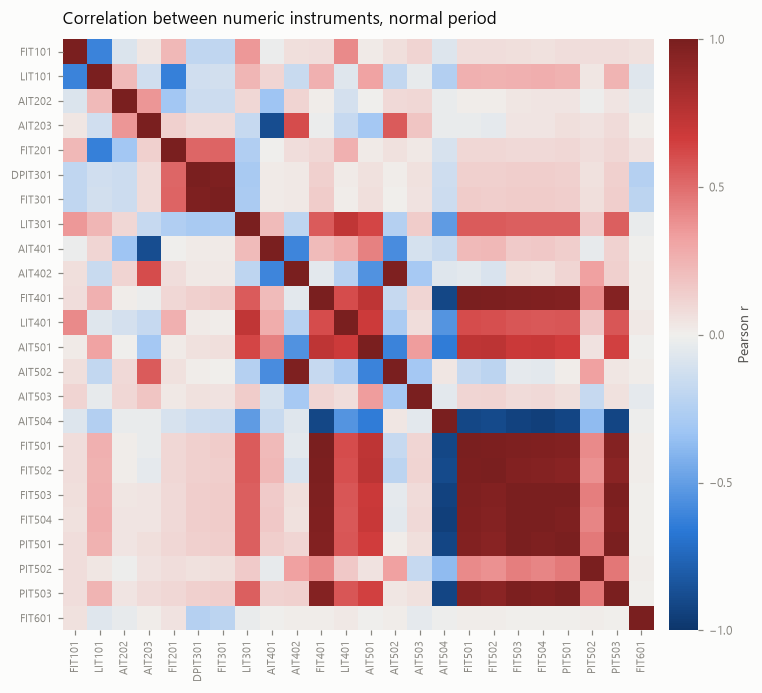

most strongly coupled pairs in the normal period:
  FIT401   ~ FIT501   r = +1.000
  PIT503   ~ PIT501   r = +0.999
  PIT501   ~ FIT503   r = +0.995
  FIT504   ~ FIT503   r = +0.993
  FIT503   ~ PIT503   r = +0.992
  FIT502   ~ FIT501   r = +0.989
  FIT502   ~ FIT401   r = +0.989
  FIT401   ~ FIT503   r = +0.983


In [30]:

corr_cols = [c for c in cont if clean_vals.loc[normal_mask, c].std() > 1e-9]
corr = clean_vals.loc[normal_mask, corr_cols].corr()

fig, ax = plt.subplots(figsize=(7.6, 6.4))
div = mpl.colors.LinearSegmentedColormap.from_list(
    "div", ["#0d366b", "#2a78d6", "#9ec5f4", "#f0efec", "#f0a0a0", "#d03b3b", "#7a1f1f"])
im = ax.imshow(corr.values, cmap=div, vmin=-1, vmax=1, aspect="equal")
ax.set_xticks(range(len(corr_cols)), corr_cols, rotation=90, fontsize=7.5)
ax.set_yticks(range(len(corr_cols)), corr_cols, fontsize=7.5)
ax.set_title("Correlation between numeric instruments, normal period")
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[-1, -0.5, 0, 0.5, 1])
cb.set_label("Pearson r", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

off = corr.where(~np.eye(len(corr), dtype=bool))
pairs = off.stack().sort_values(key=abs, ascending=False)
seen, top_pairs = set(), []
for (i, j), v in pairs.items():
    if (j, i) in seen:
        continue
    seen.add((i, j))
    top_pairs.append((i, j, round(float(v), 3)))
    if len(top_pairs) == 8:
        break
print("most strongly coupled pairs in the normal period:")
for i, j, v in top_pairs:
    print(f"  {i:<8} ~ {j:<8} r = {v:+.3f}")

The matrix shows a block structure that follows the stages: instruments in the
same stage are strongly coupled.

categorical instruments: 26   varying in the normal period: 12
Cramer's V computed over 12 columns (66 pairs), n = 496,800 rows


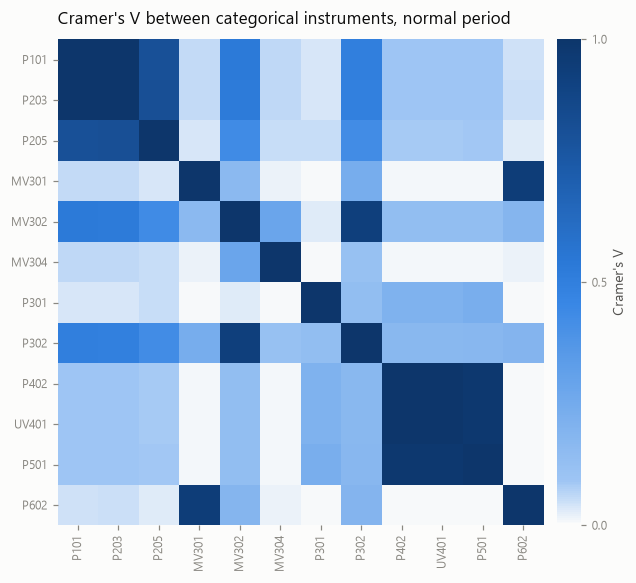

most strongly associated pairs in the normal period:
  P402     ~ UV401    V = 0.999
  P101     ~ P203     V = 0.993
  P501     ~ UV401    V = 0.977
  P402     ~ P501     V = 0.977
  P602     ~ MV301    V = 0.944
  MV302    ~ P302     V = 0.926
  P205     ~ P203     V = 0.814
  P101     ~ P205     V = 0.809

66 distinct pairs   median V = 0.092   V > 0.8: 12.1%   V > 0.5: 15.2%


In [31]:
from scipy.stats import chi2_contingency

chi_cols = [c for c in disc if clean_vals.loc[normal_mask, c].nunique() > 1]
X = clean_vals.loc[normal_mask, chi_cols]
n_normal = int(normal_mask.sum())
cram = pd.DataFrame(np.eye(len(chi_cols)), index=chi_cols, columns=chi_cols)
for i, a in enumerate(chi_cols):
    for b in chi_cols[i + 1:]:
        table = pd.crosstab(X[a], X[b])
        stat = chi2_contingency(table)[0]
        v = float(np.sqrt(stat / (n_normal * (min(table.shape) - 1))))
        cram.loc[a, b] = cram.loc[b, a] = v

print(f"categorical instruments: {len(disc)}   "
      f"varying in the normal period: {len(chi_cols)}")
print(f"Cramer's V computed over {len(chi_cols)} columns "
      f"({len(chi_cols) * (len(chi_cols) - 1) // 2} pairs), n = {n_normal:,} rows")

fig, ax = plt.subplots(figsize=(6.6, 5.4))
seq = mpl.colors.LinearSegmentedColormap.from_list("seq", ["#fcfcfb"] + SEQ[2:])
im = ax.imshow(cram.values, cmap=seq, vmin=0, vmax=1, aspect="equal")
ax.set_xticks(range(len(chi_cols)), chi_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(chi_cols)), chi_cols, fontsize=8)
ax.set_title("Cramer's V between categorical instruments, normal period")
ax.grid(visible=False)
for s in ax.spines.values():
    s.set_visible(False)
cb = fig.colorbar(im, ax=ax, fraction=0.045, pad=0.02, ticks=[0, 0.5, 1])
cb.set_label("Cramer's V", color=INK2, fontsize=9)
cb.ax.tick_params(colors=MUTED, labelsize=8)
cb.outline.set_visible(False)
fig.tight_layout()
plt.show()

off = cram.where(~np.eye(len(cram), dtype=bool)).stack().sort_values(ascending=False)
seen, top_cram = set(), []
for (i, j), v in off.items():
    if (j, i) in seen:
        continue
    seen.add((i, j))
    top_cram.append((i, j, float(v)))
    if len(top_cram) == 8:
        break
print("most strongly associated pairs in the normal period:")
for i, j, v in top_cram:
    print(f"  {i:<8} ~ {j:<8} V = {v:.3f}")

flat = cram.to_numpy()[np.triu_indices(len(cram), 1)]
print()
print(f"{len(flat)} distinct pairs   median V = {np.median(flat):.3f}   "
      f"V > 0.8: {(flat > 0.8).mean():.1%}   V > 0.5: {(flat > 0.5).mean():.1%}")

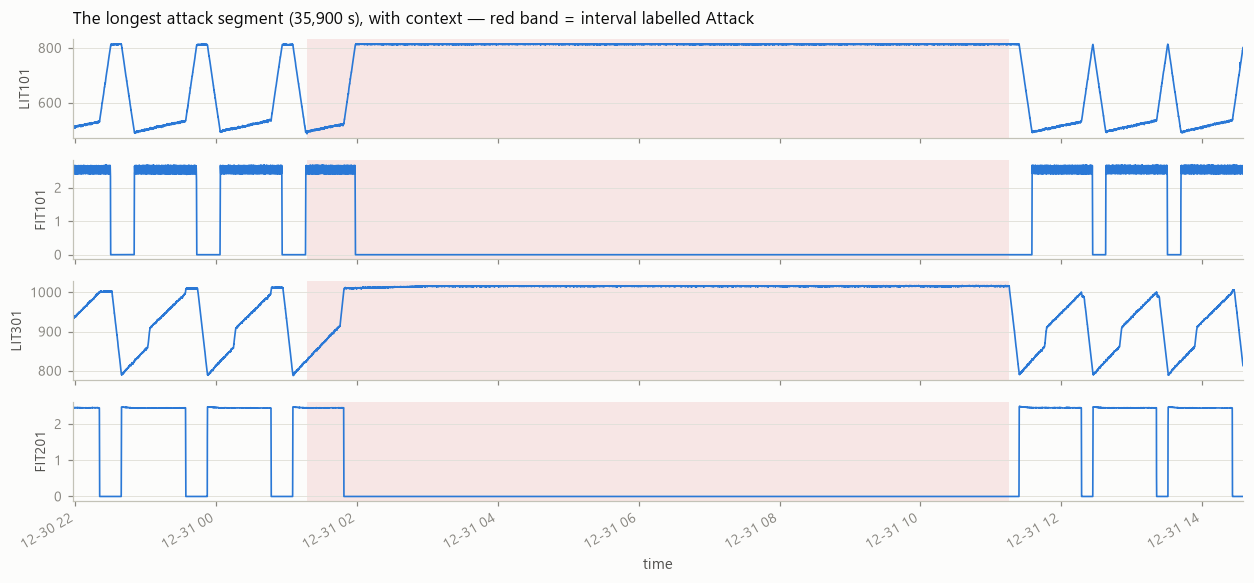

In [32]:
seg = int(np.argmax(dur))                    
a, b = starts[seg], ends[seg]
pad = (b - a) // 3
lo, hi = max(0, a - pad), min(len(clean), b + pad)
show = ["LIT101", "FIT101", "LIT301", "FIT201"]
show = [c for c in show if c in clean_vals.columns]

fig, axes = plt.subplots(len(show), 1, figsize=(11.5, 1.35 * len(show)), sharex=True)
t = clean["ts"].iloc[lo:hi]
for ax, c in zip(axes, show):
    ax.plot(t, clean_vals[c].iloc[lo:hi], color=C[0], linewidth=1.1)
    ax.axvspan(clean["ts"].iloc[a], clean["ts"].iloc[b - 1],
               color=ATTACK, alpha=0.11, linewidth=0, zorder=0)
    ax.set_ylabel(c, fontsize=9)
    ax.grid(axis="x", visible=False)
    ax.margins(x=0)
axes[0].set_title(f"The longest attack segment ({dur[seg]:,} s), with context "
                  f"— red band = interval labelled Attack")
axes[-1].set_xlabel("time")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

---
## 6. Summary

**The dataset.** 11 days at 1 Hz from a genuinely operational six-stage water
treatment plant, 51 instruments, real attacks executed on the PLCs. After
de-duplication and time-ordering: **946,719 rows**, of which 54,621 are attack
(5.77%) spread over **35 segments**.

**What has to be done before using it.**

| defect | magnitude | consequence if ignored |
|---|---|---|
| duplicate rows | 495,000 (34.3%) | every duplicate has a copy at distance zero: a neighbour-based detector scores it as normal by construction |
| rows not in time order | 3 blocks, 2 backward jumps | a temporal split would read interleaved periods |
| attacks grouped by label | 1 contiguous block in the file | segment durations are not measurable on the file as it ships |
| instruments absent in the normal period | 7 of 51 | attacks on those sensors are undetectable; 44 usable columns remain |